# Import Libraries

In [40]:
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt
from tabulate import tabulate

# How to Load .mhd Data

In [41]:
# load scan data
# .mhd is metadata file
ct = sitk.ReadImage('../dataset/lndb/data/LNDb-0001.mhd')
mask = sitk.ReadImage('../dataset/lndb/masks/LNDb-0001_rad1.mhd')

# get numpy array from SimpleITK image object
ct_volume = sitk.GetArrayFromImage(ct)
mask_volume = sitk.GetArrayFromImage(mask)

print(f'CT Size: {ct.GetSize()}')
print(f'Mask Size": {mask.GetSize()}')
print(np.unique(mask_volume))

CT Size: (512, 512, 328)
Mask Size": (512, 512, 328)
[0 1 2]


In [42]:
for key in ct.GetMetaDataKeys():
    print(key, ct.GetMetaData(key))

ITK_InputFilterName MetaImageIO
ITK_original_direction [UNKNOWN_PRINT_CHARACTERISTICS]

ITK_original_spacing [UNKNOWN_PRINT_CHARACTERISTICS]



# Explore .mhd Metadata

In [43]:
data_scan = [
    ['CT size', ct.GetSize(), type(ct.GetSize())],
    ['CT spacing', ct.GetSpacing(), type(ct.GetSpacing())],
    ['Mask size', mask.GetSize(), type(mask.GetSize())],
    ['Mask spacing', mask.GetSpacing(), type(mask.GetSpacing())],
    ['CT shape', ct_volume.shape, type(ct_volume.shape)],
    ['Mask shape', mask_volume.shape, type(mask_volume.shape)],
    ['CT min HU', ct_volume.min(), type(ct_volume.min())],
    ['CT max HU', ct_volume.max(), type(ct_volume.max())],
    ['Mask unique values', np.unique(mask_volume), type(np.unique(mask_volume))]
]

print(tabulate(
    data_scan,
    headers=['Attribute','Value','Type'],
    tablefmt='grid'
))

+--------------------+---------------------------------+-------------------------+
| Attribute          | Value                           | Type                    |
+====================+=================================+=========================+
| CT size            | (512, 512, 328)                 | <class 'tuple'>         |
+--------------------+---------------------------------+-------------------------+
| CT spacing         | (0.607421875, 0.607421875, 1.0) | <class 'tuple'>         |
+--------------------+---------------------------------+-------------------------+
| Mask size          | (512, 512, 328)                 | <class 'tuple'>         |
+--------------------+---------------------------------+-------------------------+
| Mask spacing       | (0.607421875, 0.607421875, 1.0) | <class 'tuple'>         |
+--------------------+---------------------------------+-------------------------+
| CT shape           | (328, 512, 512)                 | <class 'tuple'>         |
+---

c:\Users\filli\anaconda3\envs\nodule_py37\lib\site-packages\tabulate\__init__.py:108: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  or (len(row) >= 2 and row[1] == SEPARATING_LINE)


# Visualize Nodule using Mask

In [44]:
slices = np.where(mask_volume > 0)[0]

print(f'Mask Unique: {np.unique(mask_volume)}')
print(f'Mask Shape: {mask_volume.shape}')
print("Background:", np.sum(mask_volume == 0))
print("Label 1:", np.sum(mask_volume == 1))
print("Label 2:", np.sum(mask_volume == 2))

print(f'First slice with nodule: {slices.min()}')
print(f'Last slice with nodues: {slices.max()}')


Mask Unique: [0 1 2]
Mask Shape: (328, 512, 512)
Background: 85981624
Label 1: 1195
Label 2: 413
First slice with nodule: 249
Last slice with nodues: 263


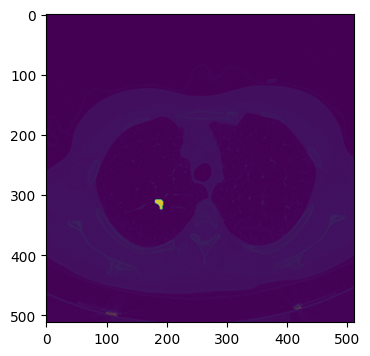

In [45]:
idx = slices[len(slices)//2]

plt.figure(figsize=(4,4))
plt.imshow(ct_volume[idx], cmap="viridis")
plt.imshow(mask_volume[idx], alpha=0.8)
plt.show()

# Visualize Nodule Mask From Multiple Radiologs

In [46]:
mask_rad1 = sitk.ReadImage("../dataset/lndb/masks/LNDb-0001_rad1.mhd")
mask_rad2 = sitk.ReadImage("../dataset/lndb/masks/LNDb-0001_rad2.mhd")
mask_rad3 = sitk.ReadImage("../dataset/lndb/masks/LNDb-0001_rad3.mhd")

rad1_np = sitk.GetArrayFromImage(mask_rad1)
rad2_np = sitk.GetArrayFromImage(mask_rad2)
rad3_np = sitk.GetArrayFromImage(mask_rad3)

In [47]:
nodule_slices = np.unique(
    np.where(rad1_np > 0)[0]
)
print(nodule_slices)

slice_idx = nodule_slices[len(nodule_slices)//2]
slice_idx = 249
print(slice_idx)

[249 250 251 252 253 254 255 256 257 258 259 260 261 262 263]
249


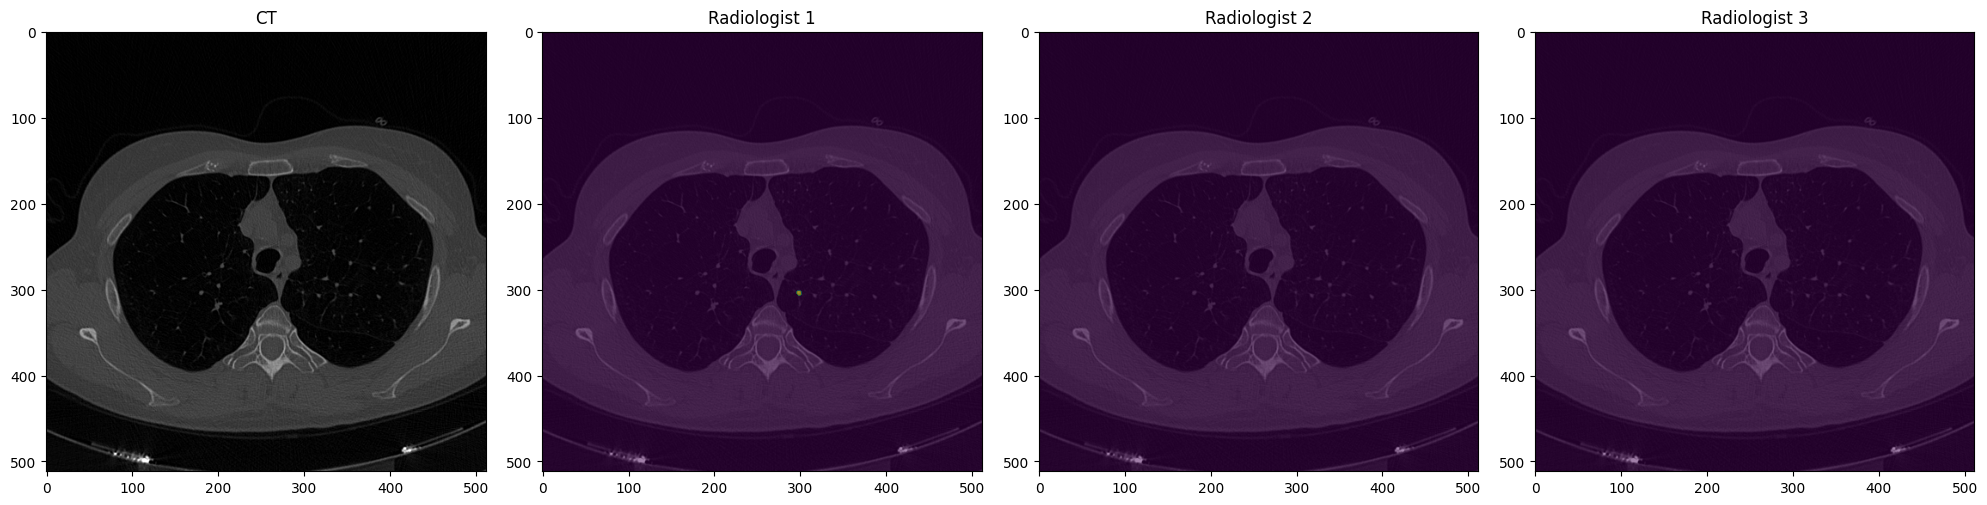

In [48]:
fig, ax = plt.subplots(1, 4, figsize=(20,5))

ax[0].imshow(ct_volume[slice_idx], cmap='gray')
ax[0].set_title("CT")

ax[1].imshow(ct_volume[slice_idx], cmap='gray')
ax[1].imshow(rad1_np[slice_idx], alpha=0.5)
ax[1].set_title("Radiologist 1")

ax[2].imshow(ct_volume[slice_idx], cmap='gray')
ax[2].imshow(rad2_np[slice_idx], alpha=0.5)
ax[2].set_title("Radiologist 2")

ax[3].imshow(ct_volume[slice_idx], cmap='gray')
ax[3].imshow(rad3_np[slice_idx], alpha=0.5)
ax[3].set_title("Radiologist 3")

plt.tight_layout()
plt.show()